In [5]:
import joblib
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score, roc_curve, classification_report, confusion_matrix
import matplotlib.pyplot as plt

In [3]:
model = joblib.load("D:\\Credit Risk Modelling\\models\\logistic_model.joblib")

In [4]:
X_test_feat = pd.read_csv('D:\\Credit Risk Modelling\\Data\\featured\\test_featured.csv')
y_test = pd.read_csv('D:\\Credit Risk Modelling\\Data\\featured\\y_test.csv')

### 1. Classification Report

In [6]:
y_pred = model.predict(X_test_feat)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.93      0.96     11390
           1       0.57      0.94      0.71      1108

    accuracy                           0.93     12498
   macro avg       0.78      0.93      0.84     12498
weighted avg       0.96      0.93      0.94     12498

[[10610   780]
 [   71  1037]]


### 2. ROC-AUC Curve

In [8]:
y_pred_proba = model.predict_proba(X_test_feat)[:, 1]
auc_score = roc_auc_score(y_test, y_pred_proba)
print(f"AUC Score: {auc_score}")
print("Gini:", 2*auc_score - 1)

AUC Score: 0.9829343936507735
Gini: 0.965868787301547


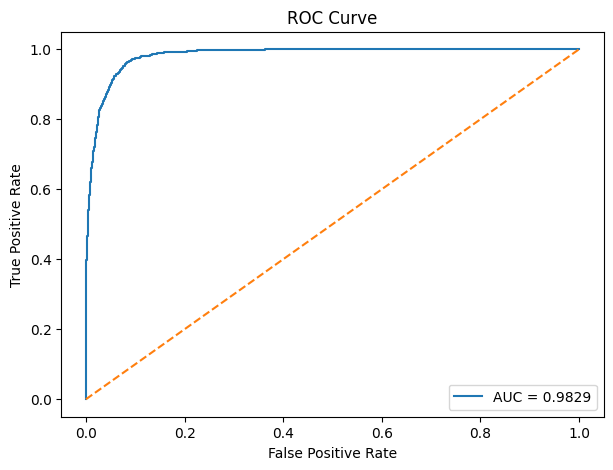

In [9]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(7, 5))

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")
plt.plot([0, 1], [0, 1], linestyle='--')  # Random model line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

### 3. Rankorder & KS Statistic

In [43]:
probabilities = model.predict_proba(X_test_feat)[:, 1]
df_kspd = pd.DataFrame({
    'Default Truth': y_test.values.flatten(),
    'Default Probability': probabilities
})

In [44]:
df_kspd['Decile'] = pd.qcut(x=df_kspd['Default Probability'], q=10, labels=False, duplicates='drop')
df_kspd.head()

,Default Truth,Default Probability,Decile
0,0,0.000006,1
1,0,0.762197,8
2,0,0.133989,7
3,0,0.396918,8
4,0,0.000828,4


In [45]:
df_kspd_grouped = df_kspd.groupby('Decile').apply(lambda x: pd.Series({
    'Minimum Probabilities': x['Default Probability'].min(),
    'Maximum Probabilities': x['Default Probability'].max(),
    'Events': x['Default Truth'].sum(),
    'Non-Events': x['Default Truth'].count() - x['Default Truth'].sum(),
}))
df_kspd_grouped.reset_index(inplace=True)
df_kspd_grouped['Event Rate'] = df_kspd_grouped['Events']*100 / (df_kspd_grouped['Events'] + df_kspd_grouped['Non-Events'])
df_kspd_grouped['Non-Event Rate'] = df_kspd_grouped['Non-Events']*100 / (df_kspd_grouped['Events'] + df_kspd_grouped['Non-Events'])
df_kspd_grouped['Cumulative Events'] = df_kspd_grouped['Events'].cumsum()
df_kspd_grouped['Cumulative Non-Events'] = df_kspd_grouped['Non-Events'].cumsum()
df_kspd_grouped['Cumulative Event Rate'] = df_kspd_grouped['Cumulative Events']*100 / df_kspd_grouped['Events'].sum()
df_kspd_grouped['Cumulative Non-Event Rate'] = df_kspd_grouped['Cumulative Non-Events']*100 / df_kspd_grouped['Non-Events'].sum()
df_kspd_grouped['KS'] = np.abs(df_kspd_grouped['Cumulative Event Rate'] - df_kspd_grouped['Cumulative Non-Event Rate'])
df_kspd_grouped.head()

,Decile,Minimum Probabilities,Maximum Probabilities,Events,Non-Events,Event Rate,Non-Event Rate,Cumulative Events,Cumulative Non-Events,Cumulative Event Rate,Cumulative Non-Event Rate,KS
0,0,1.052569e-09,8.208644e-07,0.0,1250.0,0.0,100.0,0.0,1250.0,0.0,10.974539,10.974539
1,1,8.266618e-07,6.269370e-06,0.0,1250.0,0.0,100.0,0.0,2500.0,0.0,21.949078,21.949078
2,2,6.269800e-06,3.369149e-05,0.0,1250.0,0.0,100.0,0.0,3750.0,0.0,32.923617,32.923617
3,3,3.372223e-05,1.715495e-04,0.0,1249.0,0.0,100.0,0.0,4999.0,0.0,43.889377,43.889377
4,4,1.715880e-04,8.627226e-04,0.0,1250.0,0.0,100.0,0.0,6249.0,0.0,54.863916,54.863916


In [46]:
df_kspd_grouped.sort_values(by='Decile', ascending=False).reset_index(drop=True)
df_kspd_grouped

,Decile,Minimum Probabilities,Maximum Probabilities,Events,Non-Events,Event Rate,Non-Event Rate,Cumulative Events,Cumulative Non-Events,Cumulative Event Rate,Cumulative Non-Event Rate,KS
0,0,1.052569e-09,8.208644e-07,0.0,1250.0,0.000000,100.000000,0.0,1250.0,0.000000,10.974539,10.974539
1,1,8.266618e-07,6.269370e-06,0.0,1250.0,0.000000,100.000000,0.0,2500.0,0.000000,21.949078,21.949078
2,2,6.269800e-06,3.369149e-05,0.0,1250.0,0.000000,100.000000,0.0,3750.0,0.000000,32.923617,32.923617
3,3,3.372223e-05,1.715495e-04,0.0,1249.0,0.000000,100.000000,0.0,4999.0,0.000000,43.889377,43.889377
4,4,1.715880e-04,8.627226e-04,0.0,1250.0,0.000000,100.000000,0.0,6249.0,0.000000,54.863916,54.863916
5,5,8.642878e-04,4.865501e-03,1.0,1249.0,0.080000,99.920000,1.0,7498.0,0.090253,65.829675,65.739422
6,6,4.898880e-03,3.157785e-02,2.0,1247.0,0.160128,99.839872,3.0,8745.0,0.270758,76.777875,76.507117
7,7,3.158909e-02,1.995199e-01,19.0,1231.0,1.520000,98.480000,22.0,9976.0,1.985560,87.585601,85.600042
8,8,1.995761e-01,8.201193e-01,164.0,1086.0,13.120000,86.880000,186.0,11062.0,16.787004,97.120281,80.333277
9,9,8.208815e-01,9.999999e-01,922.0,328.0,73.760000,26.240000,1108.0,11390.0,100.000000,100.000000,0.000000


In [48]:
df = pd.DataFrame({'y': y_test.values.flatten(), 'proba': y_pred_proba})
df = df.sort_values(by='proba', ascending=False)

df['cum_bad'] = df['y'].cumsum() / df['y'].sum()
df['cum_good'] = ((1-df['y']).cumsum()) / (1-df['y']).sum()
df['ks'] = df['cum_bad'] - df['cum_good']

ks = df['ks'].max()
print("KS:", ks*100)

KS: 87.99024098027594
